# Calibration diagnostics

Per-session per-cell T_sys distributions. Run `scan_load.ipynb` first
(it writes `scan_load_state.pkl` with `tsys_by_session_cell`).

In [1]:
import pickle
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

STATE_PATH = Path('artifacts/scan_load_state.pkl')
with open(STATE_PATH, 'rb') as f:
    state = pickle.load(f)

tsys_by_session_cell = state['tsys_by_session_cell']
sessions = state['sessions']
T_CAL = state.get('T_CAL_11', 79.0)

tsys_per_session = defaultdict(list)
for (sess, gl, gb), tsys in tsys_by_session_cell.items():
    tsys_per_session[sess].append(tsys)

all_tsys = np.array([t for ts in tsys_per_session.values() for t in ts])
print(f'Loaded {len(tsys_by_session_cell)} (session, cell) T_sys entries '
      f'across {len(tsys_per_session)} sessions')
print(f'Global: median={np.median(all_tsys):.1f} K, '
      f'range=[{all_tsys.min():.0f}, {all_tsys.max():.0f}] K')

Loaded 47 (session, cell) T_sys entries across 3 sessions
Global: median=215.5 K, range=[188, 268] K


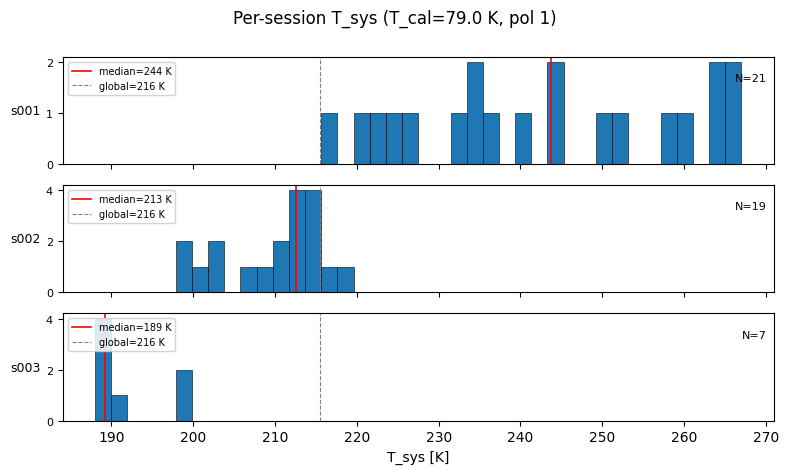

In [2]:
active_sessions = [s for s in sessions if tsys_per_session.get(s)]
n = len(active_sessions)

lo = np.floor(np.percentile(all_tsys, 1))
hi = np.ceil(np.percentile(all_tsys, 99))
bins = np.linspace(lo, hi, 41)
global_med = float(np.median(all_tsys))

fig, axes = plt.subplots(n, 1, figsize=(8, 1.4 * n + 0.5), sharex=True)
if n == 1:
    axes = [axes]

for ax, sess in zip(axes, active_sessions):
    vals = np.array(tsys_per_session[sess])
    ax.hist(vals, bins=bins, color='C0', edgecolor='black', linewidth=0.4)
    med = float(np.median(vals))
    ax.axvline(med, color='red', lw=1.2,
               label=f'median={med:.0f} K')
    ax.axvline(global_med, color='gray', ls='--', lw=0.8,
               label=f'global={global_med:.0f} K')
    ax.set_ylabel(sess.replace('session_', 's'),
                  rotation=0, ha='right', va='center', fontsize=9)
    ax.text(0.99, 0.85, f'N={len(vals)}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8)
    ax.legend(loc='upper left', fontsize=7, framealpha=0.85)
    ax.tick_params(axis='y', labelsize=8)

axes[-1].set_xlabel('T_sys [K]')
fig.suptitle(f'Per-session T_sys (T_cal={T_CAL} K, pol 1)', y=1.0)
plt.tight_layout()
plt.show()

## Random pointing: cal vs obs spectra

For one randomly chosen cell, plot raw cal (dotted) and the three obs dumps (solid)
overlaid for each (LO, polarisation) combination -- 2 columns x 2 rows.


/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Session: session_003, cell: 138p01_2
  obs dumps: 6, cal dumps: 2, LOs: [1419.86, 1421.14]


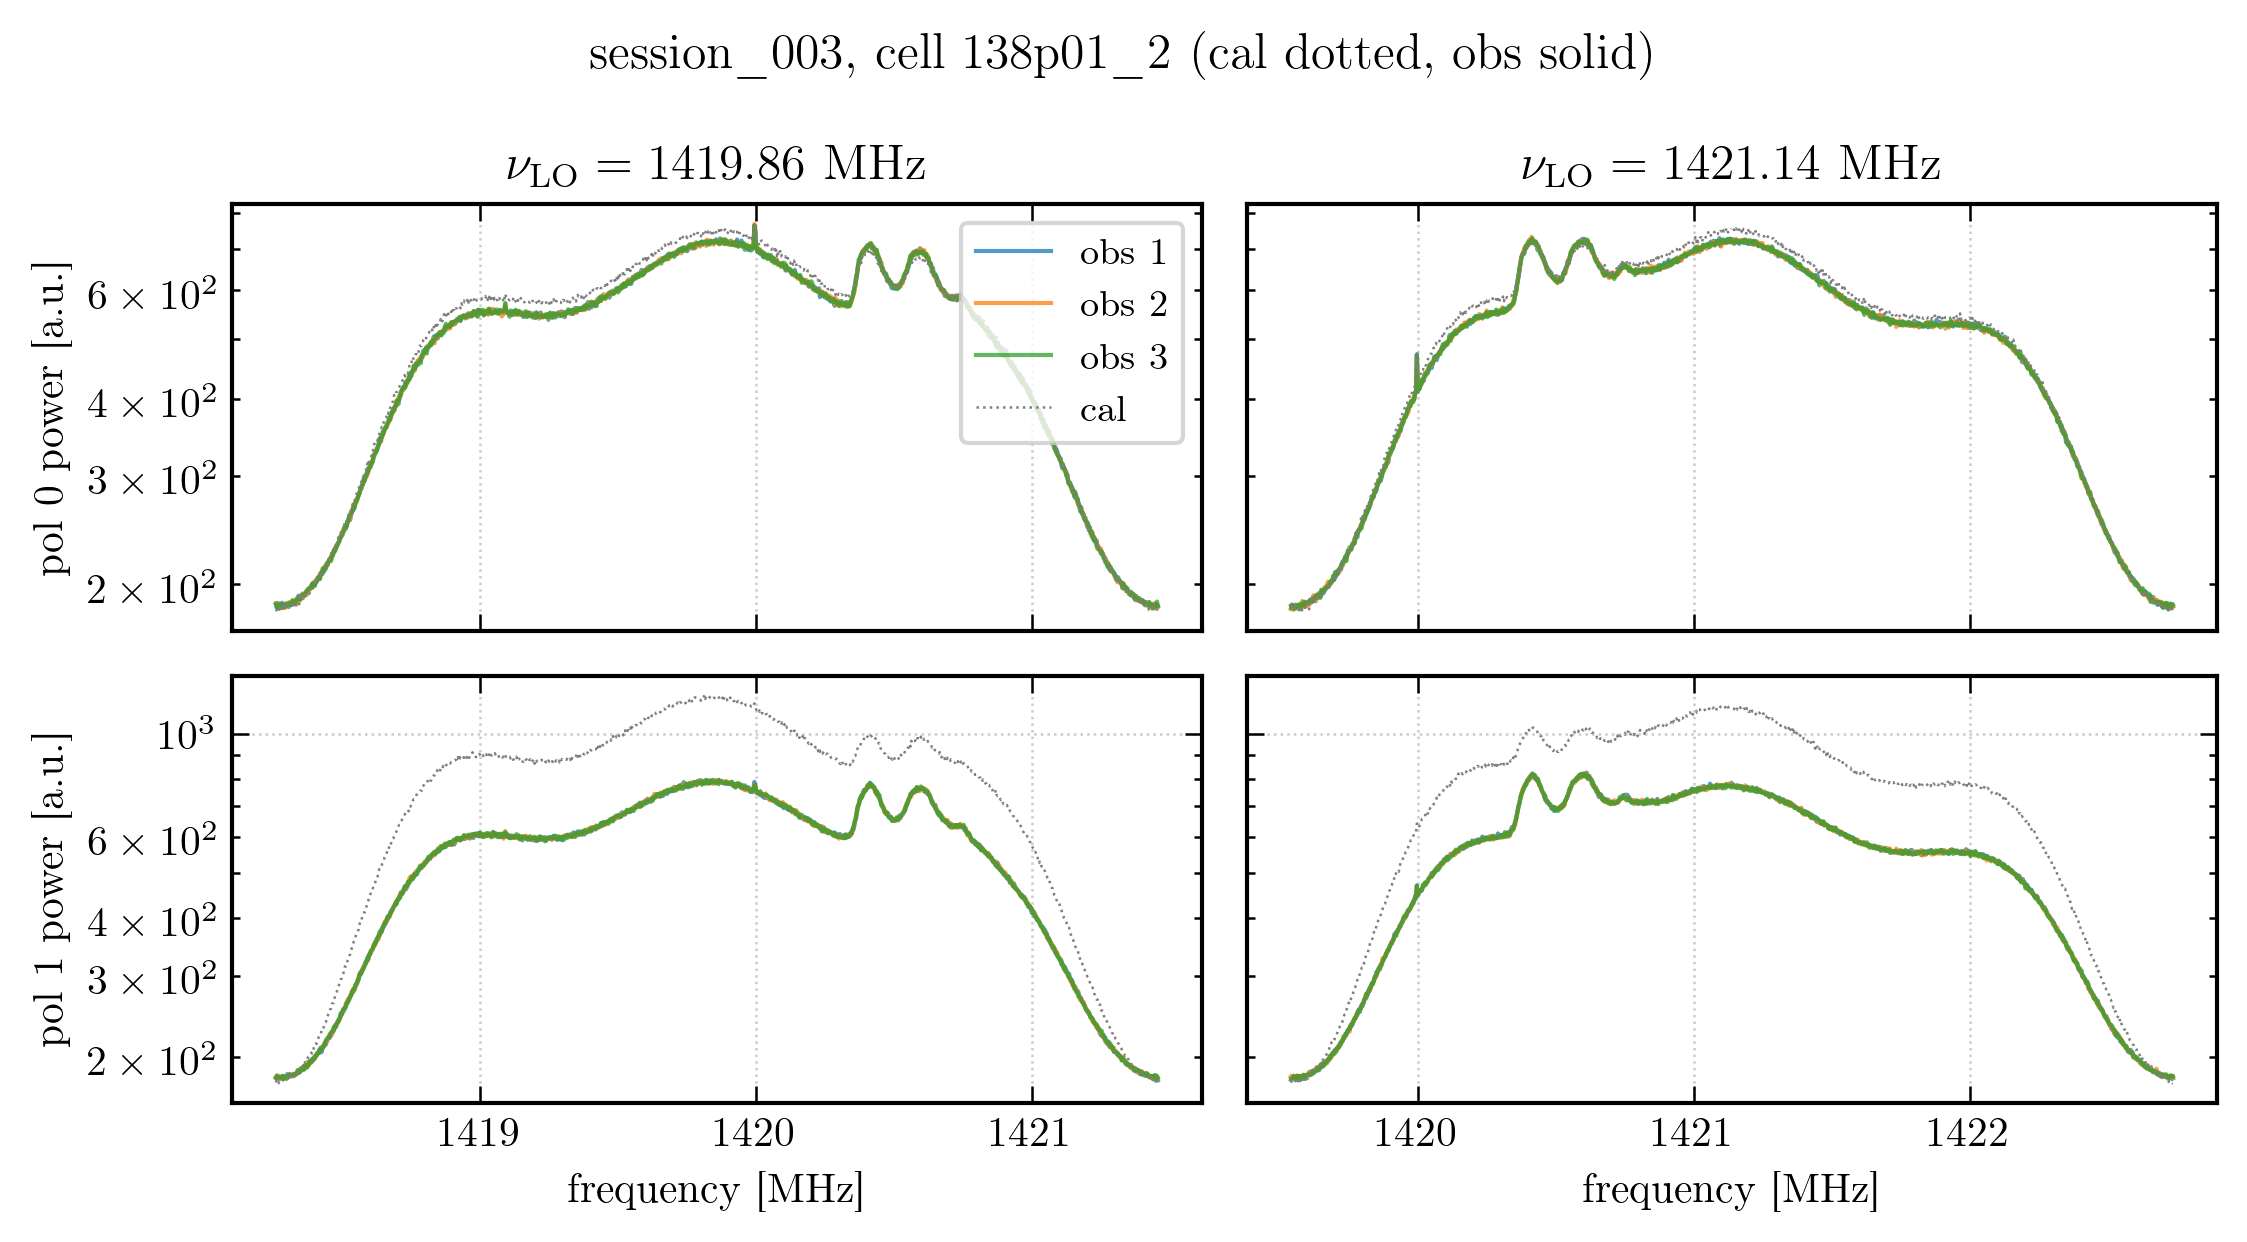

In [3]:
import glob
import random

import numpy as np
import matplotlib.pyplot as plt

from ugradiolab import plotting
from ugradiolab.plotting import LW_LIGHT, LW_FINE, ALPHA_STANDARD, NEUTRAL_COLOR

SAMPLE_RATE_MHZ = 3.2
NCHAN = 1024
DC_BIN = NCHAN // 2


def _cell_key(d):
    return Path(d).name.split('_', 1)[1]


def _shift_mask(x):
    x = np.fft.fftshift(x).astype(float)
    x[DC_BIN] = np.nan
    return x


def _load_dumps(cell_dir):
    out = []
    for npz in sorted(glob.glob(f'{cell_dir}/*.npz')):
        d = np.load(npz, allow_pickle=True)
        out.append({
            'corr00': _shift_mask(d['corr00']),
            'corr11': _shift_mask(d['corr11']),
            'lo_freq_mhz': float(d['lo_freq_mhz']),
        })
    return out


candidates = []
for sess in sorted(glob.glob('data/main/session_*')):
    obs_dirs = {_cell_key(d): d for d in glob.glob(f'{sess}/obs_*')}
    cal_dirs = {_cell_key(d): d for d in glob.glob(f'{sess}/cal_*')}
    for k in obs_dirs.keys() & cal_dirs.keys():
        candidates.append((sess, k, obs_dirs[k], cal_dirs[k]))

if not candidates:
    raise SystemExit('No cells with paired cal+obs found under data/main/')

sess, cell_key, obs_dir, cal_dir = random.choice(candidates)
obs_dumps = _load_dumps(obs_dir)
cal_dumps = _load_dumps(cal_dir)

los = sorted({d['lo_freq_mhz'] for d in obs_dumps + cal_dumps})
print(f'Session: {Path(sess).name}, cell: {cell_key}')
print(f'  obs dumps: {len(obs_dumps)}, cal dumps: {len(cal_dumps)}, LOs: {los}')

f_bb_mhz = np.fft.fftshift(
    np.fft.fftfreq(NCHAN, d=1.0 / (SAMPLE_RATE_MHZ * 1e6))
) / 1e6

pols = [('corr00', r'pol 0'), ('corr11', r'pol 1')]

fig, axes = plt.subplots(
    2, 2,
    figsize=(plotting.TEXTWIDTH_IN, plotting.TEXTWIDTH_IN * 0.55),
    sharex='col', sharey='row',
)
for col, lo in enumerate(los):
    f = lo + f_bb_mhz
    obs_lo = [d for d in obs_dumps if abs(d['lo_freq_mhz'] - lo) < 0.05]
    cal_lo = [d for d in cal_dumps if abs(d['lo_freq_mhz'] - lo) < 0.05]
    for row, (key, label) in enumerate(pols):
        ax = axes[row, col]
        for i, d in enumerate(obs_lo):
            ax.plot(f, d[key], lw=LW_LIGHT, alpha=ALPHA_STANDARD,
                    label=f'obs {i+1}' if row == 0 and col == 0 else None)
        for d in cal_lo:
            ax.plot(f, d[key], lw=LW_FINE, ls=':', color=NEUTRAL_COLOR,
                    label='cal' if row == 0 and col == 0 else None)
        ax.set_yscale('log')
        if col == 0:
            ax.set_ylabel(rf'{label} power [a.u.]')
        if row == 1:
            ax.set_xlabel(r'frequency [MHz]')
        if row == 0:
            ax.set_title(rf'$\nu_\mathrm{{LO}} = {lo:.2f}$ MHz')

axes[0, 0].legend(loc='upper right')
fig.suptitle(rf'{Path(sess).name.replace("_", r"\_")}, cell {cell_key.replace("_", r"\_")} (cal dotted, obs solid)')
fig.tight_layout()
plt.show()
